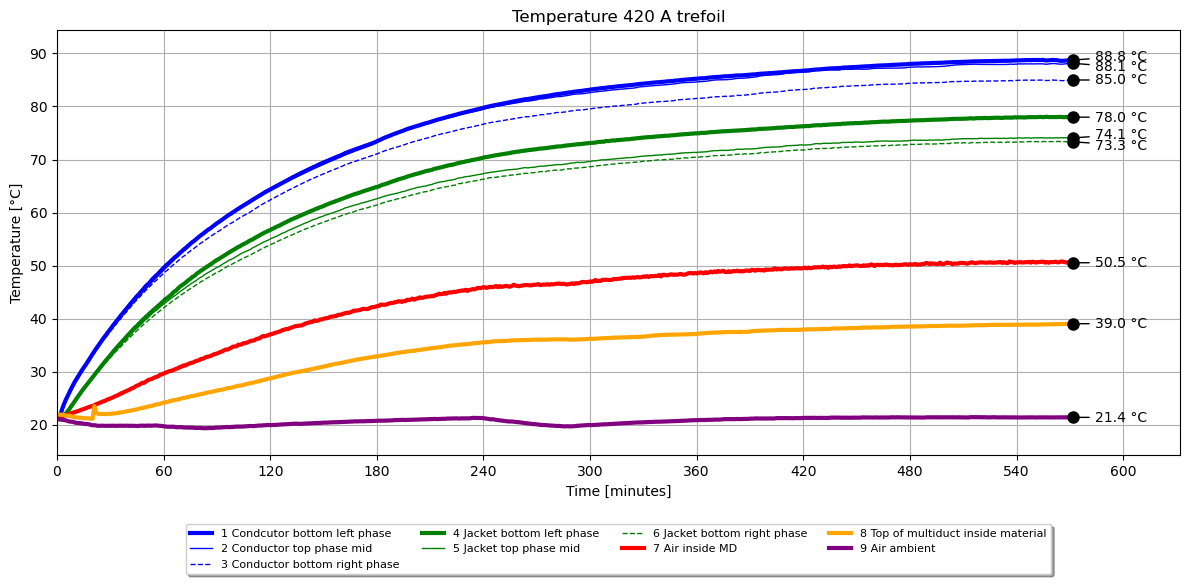

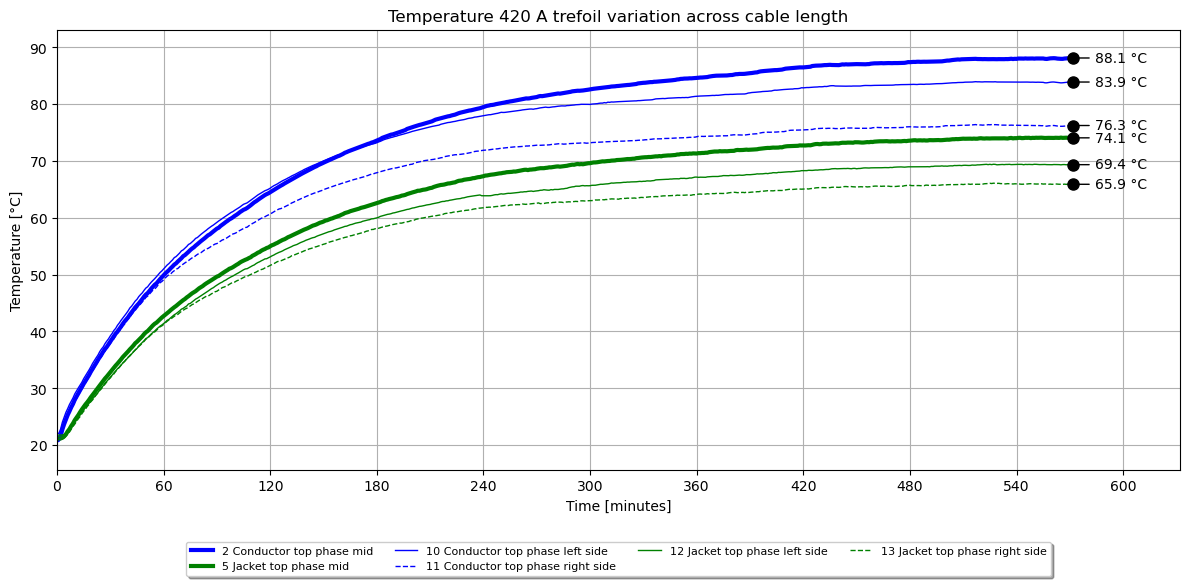

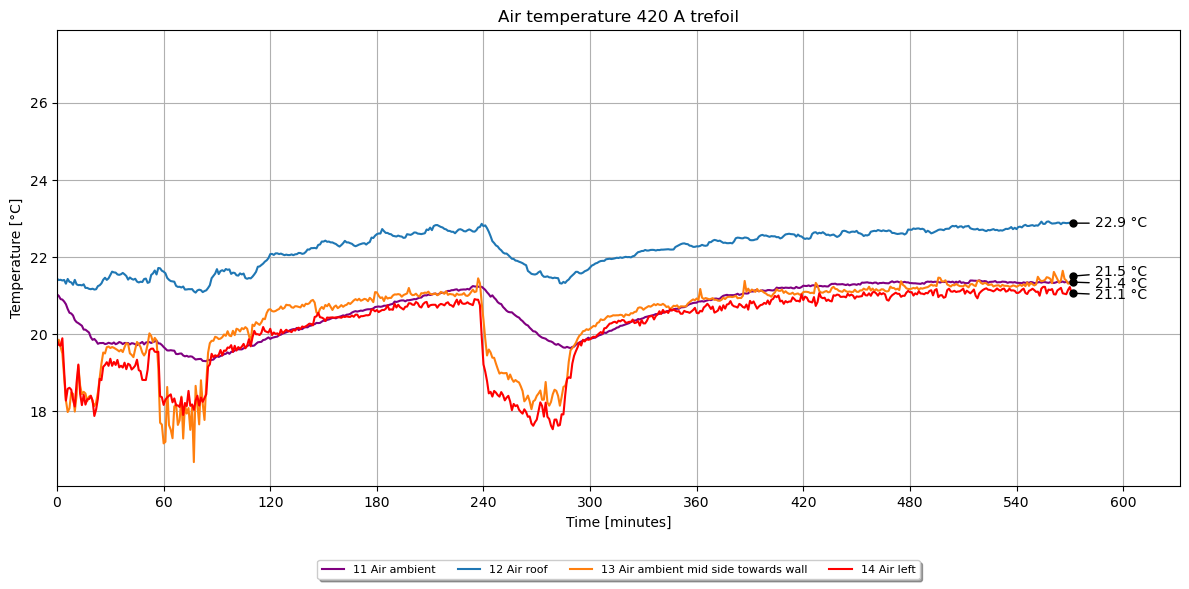

Data header row used: 24
Rows in original file: 3438
Rows after keeping every 6th sample: 573
Detected measurement columns:
  - 101 <Conductor top phase left side> (C)
  - 102 <Jacket top phase left side> (C)
  - 103 <Air left> (C)
  - 201 <Conductor top phase right side> (C)
  - 202 <Jacket top phase right side> (C)
  - 301 <Air roof> (C)
  - 302 <Conductor top phase mid> (C)
  - 303 <Jacket top phase mid> (C)
  - 304 <Conductor bottom right phase> (C)
  - 305 <Jacket bottom right phase> (C)
  - 307 <Condcutor bottom left phase> (C)
  - 308 <Jacket bottom left phase> (C)
  - 309 <Air inside MD> (C)
  - 313 <Top of multiduct inside material> (C)
  - 314 <Air ambient> (C)
  - 315 <Air ambient mid side towards wall> (C)

Detected air columns for air plot:
  - 103 <Air left> (C) -> 14 Air left
  - 301 <Air roof> (C) -> 12 Air roof
  - 314 <Air ambient> (C) -> 11 Air ambient
  - 315 <Air ambient mid side towards wall> (C) -> 13 Air ambient mid side towards wall

Final temperatures (last re

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#do not change min_gap
def spread_labels(y_values, min_gap=5.5):
    y_values = np.array(y_values, dtype=float)
    n = len(y_values)
    if n == 0:
        return y_values

    adjusted = y_values.copy()
    order = np.argsort(adjusted)

    # Iteratively push overlapping label pairs apart symmetrically until stable.
    for _ in range(300):
        moved = False
        for i in range(1, n):
            prev_idx = order[i - 1]
            curr_idx = order[i]
            gap = adjusted[curr_idx] - adjusted[prev_idx]
            if gap < min_gap:
                mid = (adjusted[prev_idx] + adjusted[curr_idx]) / 2
                adjusted[prev_idx] = mid - min_gap / 2
                adjusted[curr_idx] = mid + min_gap / 2
                moved = True
        if not moved:
            break

    return adjusted


def build_global_column_mapping(df_last_row, excluded_columns):
    ordered = [
        col for col in df_last_row.sort_values(ascending=False).index.tolist()
        if col not in excluded_columns
    ]

    mapping = {}
    for i, col in enumerate(ordered, start=1):
        clean_name = col.replace('<', '').replace('>', '').replace('(C)', '').strip()
        parts = clean_name.split(' ', 1)
        descriptive_part = parts[1] if len(parts) > 1 else clean_name
        mapping[col] = f"{i} {descriptive_part}"

    return ordered, mapping


def find_data_header_row(file_path, encoding='utf-16'):
    with open(file_path, 'r', encoding=encoding) as f:
        for i, line in enumerate(f):
            if line.startswith('Scan,Time,'):
                return i
    raise ValueError(f"Could not find data header row in {file_path}")


def plot_temperature_data(df, title, global_column_mapping, use_role_colors=False):
    if df.empty or df.shape[1] == 0:
        print(f"Skipping '{title}': no columns available to plot.")
        return

    plt.figure(figsize=(12, 6))
    cols_sorted = sorted(
        df.columns,
        key=lambda col: int(global_column_mapping[col].split()[0])
    )

    if not cols_sorted:
        print(f"Skipping '{title}': no mapped columns available to plot.")
        return

    role_style_by_col = {}
    if use_role_colors:
        style_sequence = [
            (3, '-'),
            (1, '-'),
            (1, '--'),
        ]

        conductor_cols = [
            c for c in cols_sorted
            if ('conductor' in global_column_mapping[c].lower() or 'condcutor' in global_column_mapping[c].lower())
        ]
        jacket_cols = [
            c for c in cols_sorted
            if 'jacket' in global_column_mapping[c].lower()
        ]

        for role_cols in [conductor_cols, jacket_cols]:
            # Assign style by last-value rank so each role gets thick, thin, dashed.
            role_cols_sorted = sorted(role_cols, key=lambda c: df[c].iloc[-1], reverse=True)
            for idx, c in enumerate(role_cols_sorted):
                style_idx = idx if idx < len(style_sequence) else len(style_sequence) - 1
                role_style_by_col[c] = style_sequence[style_idx]

    for col in cols_sorted:
        label = global_column_mapping[col]
        num = int(label.split()[0])

        if 1 <= num <= 3:
            color = 'blue'
            linewidth = 3 if num == 1 else 1
            linestyle = '-' if num in [1, 2] else '--'
        elif 4 <= num <= 6:
            color = 'green'
            linewidth = 3 if num == 4 else 1
            linestyle = '-' if num in [4, 5] else '--'
        elif 7 <= num <= 9:
            color = 'red'
            linewidth = 3
            linestyle = '-'
        else:
            color = 'orange' if num == 10 else 'purple'
            linewidth = 2
            linestyle = '-'

        label_lower = label.lower()
        if 'air inside md' in label_lower:
            color = 'red'
        elif 'top of multiduct inside material' in label_lower:
            color = 'orange'
        elif 'air ambient' in label_lower and 'mid side' not in label_lower:
            color = 'purple'

        if use_role_colors:
            if 'jacket' in label_lower:
                color = 'green'
            elif 'conductor' in label_lower or 'condcutor' in label_lower:
                color = 'blue'

            if col in role_style_by_col:
                linewidth, linestyle = role_style_by_col[col]

        plt.plot(
            df.index,
            df[col],
            label=label,
            color=color,
            linewidth=linewidth,
            linestyle=linestyle
        )

    last_idx = df.index[-1]
    label_x_offset = 12
    right_grid_padding = 60
    last_values = [df[col].iloc[-1] for col in cols_sorted]
    adjusted_last_y = spread_labels(last_values, min_gap=2.0)

    for y_point, y_text in zip(last_values, adjusted_last_y):
        plt.plot(last_idx, y_point, marker='o', markersize=8, color='black')
        plt.annotate(
            f"{y_point:.1f} °C",
            xy=(last_idx, y_point),
            xytext=(last_idx + label_x_offset, y_text),
            textcoords='data',
            fontsize=10,
            ha='left',
            va='center',
            arrowprops=dict(arrowstyle='-', color='black', lw=1)
        )

    data_min = df[cols_sorted].min().min()
    data_max = df[cols_sorted].max().max()
    y_min = min(data_min, min(last_values)) - 5
    y_max = max(data_max, max(adjusted_last_y), max(last_values)) + 5

    plt.xlabel('Time [minutes]')
    plt.ylabel('Temperature [°C]')
    plt.title(title)
    plt.ylim(y_min, y_max)
    plt.xlim(df.index.min(), df.index.max() + right_grid_padding)
    plt.xticks(np.arange(df.index.min(), df.index.max() + right_grid_padding + 1, 60))
    plt.grid(True)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=4, fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_air_temperature_data(df, columns, title, air_column_mapping):
    if df.empty:
        print(f"Skipping '{title}': no air rows available to plot.")
        return

    cols_sorted = [c for c in columns if c in df.columns and c in air_column_mapping]
    cols_sorted = sorted(cols_sorted, key=lambda col: int(air_column_mapping[col].split()[0]))

    if not cols_sorted:
        print(f"Skipping '{title}': no recognized air columns found.")
        return

    plt.figure(figsize=(12, 6))
    max_value = df[cols_sorted].max().max()

    for col in cols_sorted:
        label = air_column_mapping[col]
        color = None
        if label.startswith('11 Air ambient'):
            color = 'purple'
        elif 'Air left' in label:
            color = 'red'

        plt.plot(df.index, df[col], label=label, color=color)

    last_idx = df.index[-1]
    label_x_offset = 12
    right_grid_padding = 60
    last_values = [df[col].iloc[-1] for col in cols_sorted]
    adjusted_last_y = spread_labels(last_values, min_gap=0.3)

    for y_point, y_text in zip(last_values, adjusted_last_y):
        plt.plot(last_idx, y_point, marker='o', markersize=5, color='black')
        plt.annotate(
            f"{y_point:.1f} °C",
            xy=(last_idx, y_point),
            xytext=(last_idx + label_x_offset, y_text),
            textcoords='data',
            fontsize=10,
            ha='left',
            va='center',
            arrowprops=dict(arrowstyle='-', color='black', lw=1)
        )

    y_min = min(last_values) - 5
    y_max = max(max_value + 2.5, max(adjusted_last_y) + 2, max(last_values) + 5)

    plt.xlabel('Time [minutes]')
    plt.ylabel('Temperature [°C]')
    plt.title(title)
    plt.ylim(y_min, y_max)
    plt.xlim(df.index.min(), df.index.max() + right_grid_padding)
    plt.xticks(np.arange(df.index.min(), df.index.max() + right_grid_padding + 1, 60))
    plt.grid(True)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=4, fontsize=8)
    plt.tight_layout()
    plt.show()


# Load and process 420 A trefoil measurement data (no COMSOL file yet)
meas_file = r"420 A trefoil.csv"
header_row = find_data_header_row(meas_file)
df_raw_full = pd.read_csv(
    meas_file,
    encoding='utf-16',
    sep=',',
    skiprows=header_row
)

# Keep every 6th sample to reduce oversampling, then reset index for clean plotting.
df_raw = df_raw_full.iloc[::6].reset_index(drop=True)

# Detect measurement columns from actual file schema
measurement_columns = [
    col for col in df_raw.columns
    if ('<' in str(col) and '>' in str(col) and '(C)' in str(col))
]

# Fallback if naming differs but still includes angle-bracket sensor naming
if not measurement_columns:
    measurement_columns = [
        col for col in df_raw.columns
        if ('<' in str(col) and '>' in str(col))
    ]

if not measurement_columns:
    raise ValueError('No measurement temperature columns found in 420 A trefoil.csv')

df = df_raw[measurement_columns].copy()

excluded_columns = {
    '103 <Air left> (C)',
    '301 <Air roof> (C)',
    '315 <Air ambient mid side towards wall> (C)',
    '101 <Air left> (C)',
    '102 <Air mid opposite side of 309> (C)',
    '103 <Air right> (C)',
}

ordered_columns_base, _ = build_global_column_mapping(df.iloc[-1], excluded_columns)

# Safety fallback: if exclusions remove too much, use all detected measurement columns
if not ordered_columns_base:
    ordered_columns_base = df.iloc[-1].sort_values(ascending=False).index.tolist()

air_column_mapping = {}
for col in measurement_columns:
    col_lower = col.lower()
    if 'air ambient>' in col_lower:
        air_column_mapping[col] = '11 Air ambient'
    elif 'air roof' in col_lower:
        air_column_mapping[col] = '12 Air roof'
    elif 'ambient mid side towards wall' in col_lower or 'mid opposite side of 309' in col_lower:
        air_column_mapping[col] = '13 Air ambient mid side towards wall'
    elif 'air left' in col_lower:
        air_column_mapping[col] = '14 Air left'
    elif 'air right' in col_lower:
        air_column_mapping[col] = '15 Air right'

# First main plot: drop 4, 6, 9, 10 from the base order
drop_from_first_plot = {4, 6, 9, 10}
first_plot_columns = [
    col for idx, col in enumerate(ordered_columns_base, start=1)
    if idx not in drop_from_first_plot
]

# Plot 1 determines numbering: assign numbers to Plot 1 columns first,
# then append the remaining columns after.
remaining_columns = [col for col in ordered_columns_base if col not in first_plot_columns]
ordered_columns = first_plot_columns + remaining_columns

global_column_mapping = {}
for i, col in enumerate(ordered_columns, start=1):
    clean_name = col.replace('<', '').replace('>', '').replace('(C)', '').strip()
    parts = clean_name.split(' ', 1)
    descriptive_part = parts[1] if len(parts) > 1 else clean_name
    global_column_mapping[col] = f"{i} {descriptive_part}"

if first_plot_columns:
    plot_temperature_data(
        df[first_plot_columns],
        'Temperature 420 A trefoil',
        global_column_mapping
    )
else:
    print('First plot skipped: no columns left after dropping 4, 6, 9, 10.')

# Second main plot: include base-order channels 2, 4, 6, 7, 9, 10
second_plot_target_numbers = {2, 4, 6, 7, 9, 10}
second_plot_columns = [
    col for idx, col in enumerate(ordered_columns_base, start=1)
    if idx in second_plot_target_numbers
]

if second_plot_columns:
    plot_temperature_data(
        df[second_plot_columns],
        'Temperature 420 A trefoil variation across cable length',
        global_column_mapping,
        use_role_colors=True
    )
else:
    print('Second plot skipped: none of channels 2, 4, 6, 7, 9, 10 were found.')

air_columns = [col for col in measurement_columns if col in air_column_mapping]
if air_columns:
    air_df = df_raw[air_columns]
    plot_air_temperature_data(
        air_df,
        air_columns,
        'Air temperature 420 A trefoil',
        air_column_mapping
    )
else:
    print('No recognized air columns found for dedicated air plot.')

final_temps = pd.DataFrame({'420A_trefoil': df.iloc[-1]})
final_temps = final_temps.loc[ordered_columns]
final_temps = final_temps.sort_values(by='420A_trefoil', ascending=False)
final_temps.index = [global_column_mapping[col] for col in final_temps.index]

print(f'Data header row used: {header_row}')
print(f'Rows in original file: {len(df_raw_full)}')
print(f'Rows after keeping every 6th sample: {len(df_raw)}')
print('Detected measurement columns:')
for col in measurement_columns:
    print(f'  - {col}')

print('\nDetected air columns for air plot:')
for col in air_columns:
    print(f'  - {col} -> {air_column_mapping[col]}')

print('\nFinal temperatures (last recorded value), sorted descending:')
print(final_temps)
